In [13]:
#Imports & Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

base_path = r"C:\Users\shrut\OneDrive\Desktop\Mutual fund analytics"

nav = pd.read_csv(f"{base_path}/data/processed/nav_history_clean.csv")
performance = pd.read_csv(f"{base_path}/data/processed/scheme_performance_clean.csv")
benchmark = pd.read_csv(f"{base_path}/data/processed/benchmark_indices_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Datasets Loaded")

Datasets Loaded


In [14]:
#Daily Returns
nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

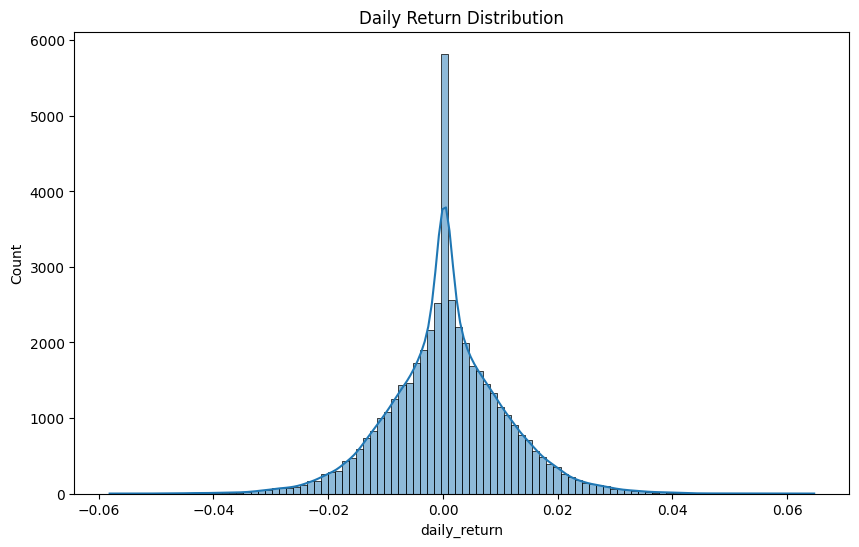

In [15]:
#Return Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")
plt.show()

In [16]:
#CAGR Calculation
cagr_list = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] - df.iloc[0]["date"]).days
    ) / 365

    cagr = ((end_nav/start_nav)**(1/years)-1)*100

    cagr_list.append([fund,cagr])

cagr_df = pd.DataFrame(
    cagr_list,
    columns=["amfi_code","CAGR"]
)

cagr_df.head()

,amfi_code,CAGR
0,100016,2.635246
1,100025,4.455091
2,100033,30.099704
3,101206,23.520489
4,101207,7.933121


In [17]:
#Sharpe Ratio
RF = 0.065

sharpe_list = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"]==fund
    ]["daily_return"].dropna()

    sharpe = (
        ((r.mean()*252)-RF)
        /
        (r.std()*np.sqrt(252))
    )

    sharpe_list.append([fund,sharpe])

sharpe_df = pd.DataFrame(
    sharpe_list,
    columns=["amfi_code","Sharpe"]
)

sharpe_df.sort_values(
    "Sharpe",
    ascending=False
).head()

,amfi_code,Sharpe
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [18]:
#Sortino Ratio
sortino_list = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"]==fund
    ]["daily_return"].dropna()

    downside = r[r<0]

    sortino = (
        ((r.mean()*252)-RF)
        /
        (downside.std()*np.sqrt(252))
    )

    sortino_list.append([fund,sortino])

sortino_df = pd.DataFrame(
    sortino_list,
    columns=["amfi_code","Sortino"]
)

sortino_df.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [19]:
#Alpha Beta
nifty = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

nifty["benchmark_return"] = nifty[
    "close_value"
].pct_change()

alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"]==fund
    ][["date","daily_return"]]

    merged = pd.merge(
        fund_df,
        nifty[["date","benchmark_return"]],
        on="date"
    ).dropna()

    if len(merged)>30:

        slope, intercept, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        alpha = intercept*252
        beta = slope

        alpha_beta.append([
            fund,
            alpha,
            beta
        ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=["amfi_code","alpha","beta"]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [20]:
#Save Alpha Beta
alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [21]:
#Maximum Drawdown
drawdown_list = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"]==fund
    ].copy()

    df["running_max"] = df["nav"].cummax()

    df["drawdown"] = (
        df["nav"]/df["running_max"]
    ) - 1

    max_dd = df["drawdown"].min()

    drawdown_list.append([
        fund,
        max_dd
    ])

drawdown_df = pd.DataFrame(
    drawdown_list,
    columns=["amfi_code","max_drawdown"]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [23]:
#Fund Scorecard

scorecard = performance.copy()

# Merge Sharpe
scorecard = scorecard.merge(
    sharpe_df,
    on="amfi_code",
    how="left"
)

# Merge Alpha Beta
scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code",
    how="left",
    suffixes=("_old", "_new")
)

# Merge Drawdown
scorecard = scorecard.merge(
    drawdown_df,
    on="amfi_code",
    how="left"
)

# Check which alpha column exists
if "alpha_new" in scorecard.columns:
    alpha_col = "alpha_new"
elif "alpha" in scorecard.columns:
    alpha_col = "alpha"
elif "alpha_old" in scorecard.columns:
    alpha_col = "alpha_old"
else:
    raise Exception("Alpha column not found")

# Ranking Metrics
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(pct=True)

scorecard["sharpe_rank"] = scorecard["Sharpe"].rank(pct=True)

scorecard["alpha_rank"] = scorecard[alpha_col].rank(pct=True)

scorecard["expense_rank"] = (
    1 - scorecard["expense_ratio_pct"].rank(pct=True)
)

scorecard["dd_rank"] = (
    1 - scorecard["max_drawdown"].rank(pct=True)
)

# Composite Score
scorecard["fund_score"] = (
      scorecard["return_rank"] * 30
    + scorecard["sharpe_rank"] * 25
    + scorecard["alpha_rank"] * 20
    + scorecard["expense_rank"] * 15
    + scorecard["dd_rank"] * 10
)

# Sort Best to Worst
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

# Show Top Funds
scorecard[
    [
        "amfi_code",
        "scheme_name",
        "fund_score"
    ]
].head(10)

,amfi_code,scheme_name,fund_score
2,119598,SBI Small Cap Fund - Regular Plan - Growth,82.7500
12,120505,ICICI Pru Midcap Fund - Regular - Growth,81.6250
39,149324,DSP Small Cap Fund - Regular - Growth,77.3125
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,75.3750
22,120843,Kotak Flexicap Fund - Regular - Growth,74.6250
26,119094,Axis Midcap Fund - Regular - Growth,69.6250
38,149323,DSP Midcap Fund - Regular - Growth,68.3750
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,68.1250
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,62.3750
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,62.0625


In [24]:
#Save Fund Scorecard
scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved successfully!")

fund_scorecard.csv saved successfully!


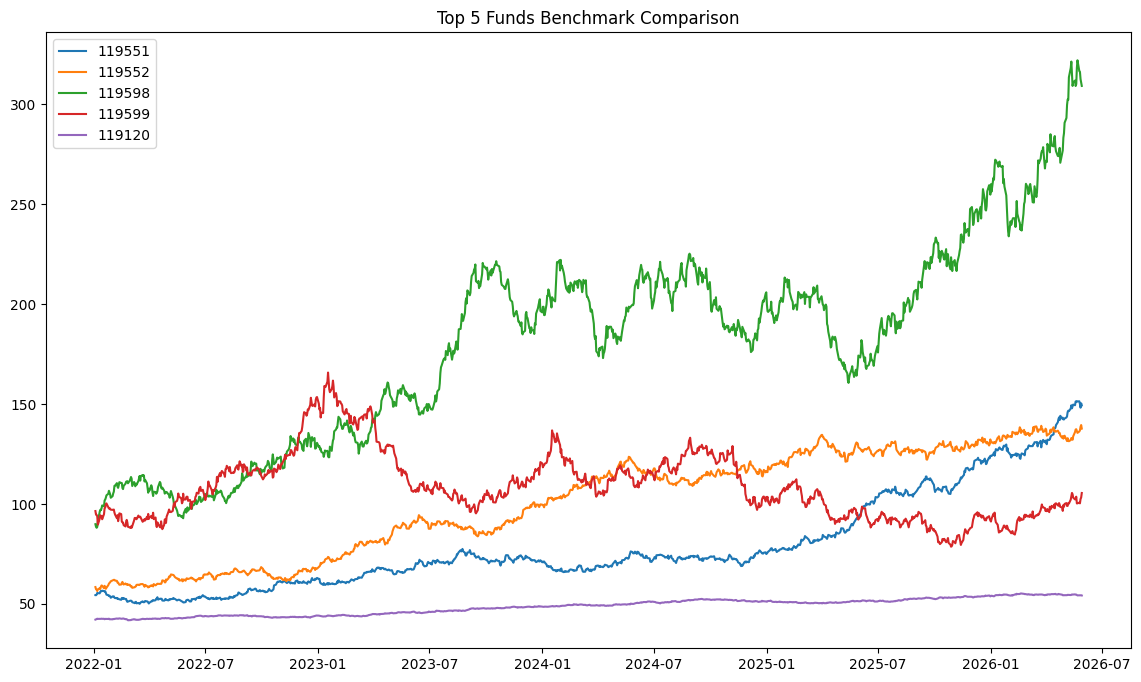

In [ ]:
#Benchmark Comparison
top5 = scorecard.head(5)["amfi_code"]

plt.figure(figsize=(14,8))

for fund in top5:

    df = nav[
        nav["amfi_code"]==fund
    ]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(fund)
    )

plt.legend()

plt.title(
    "Top 5 Funds Benchmark Comparison"
)

plt.savefig(
    "benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

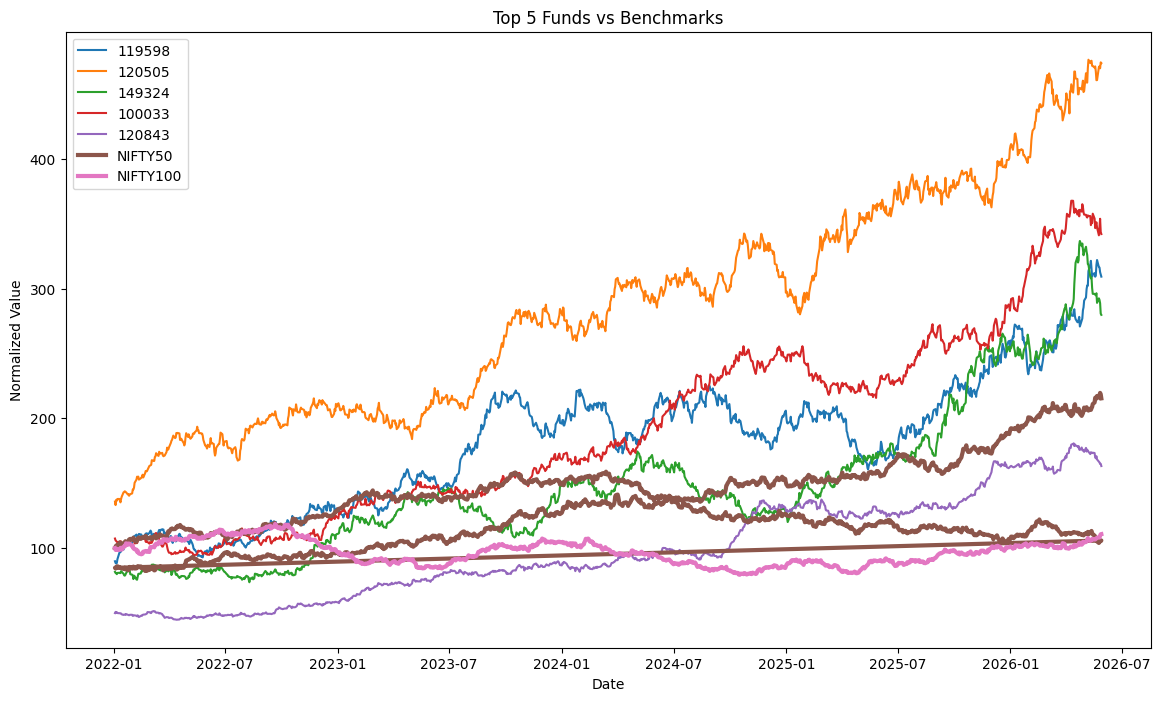

In [25]:
# Benchmark Comparison

top5 = scorecard.head(5)["amfi_code"].tolist()

plt.figure(figsize=(14,8))

for fund in top5:

    df = nav[nav["amfi_code"] == fund]

    plt.plot(
        df["date"],
        df["nav"],
        label=str(fund)
    )

# NIFTY 50
nifty50 = benchmark[
    benchmark["index_name"].str.upper().str.contains("NIFTY50", na=False)
]

if len(nifty50) > 0:
    plt.plot(
        nifty50["date"],
        nifty50["close_value"] /
        nifty50["close_value"].iloc[0] * 100,
        linewidth=3,
        label="NIFTY50"
    )

# NIFTY 100
nifty100 = benchmark[
    benchmark["index_name"].str.upper().str.contains("NIFTY100", na=False)
]

if len(nifty100) > 0:
    plt.plot(
        nifty100["date"],
        nifty100["close_value"] /
        nifty100["close_value"].iloc[0] * 100,
        linewidth=3,
        label="NIFTY100"
    )

plt.title("Top 5 Funds vs Benchmarks")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()

plt.savefig(
    "benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [26]:
#Tracking Error
tracking_error_list = []

for fund in top5:

    fund_df = nav[
        nav["amfi_code"] == fund
    ].copy()

    fund_df["fund_return"] = fund_df["nav"].pct_change()

    merged = pd.merge(
        fund_df[["date","fund_return"]],
        nifty100[["date","close_value"]],
        on="date"
    )

    merged["benchmark_return"] = (
        merged["close_value"].pct_change()
    )

    merged = merged.dropna()

    tracking_error = (
        (merged["fund_return"] -
         merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error_list.append(
        [fund, tracking_error]
    )

tracking_error_df = pd.DataFrame(
    tracking_error_list,
    columns=["amfi_code","tracking_error"]
)

tracking_error_df

,amfi_code,tracking_error
0,119598,0.283881
1,120505,0.231968
2,149324,0.279170
3,100033,0.228699
4,120843,0.206425


In [27]:
#Save Tracking Error
tracking_error_df.to_csv(
    "tracking_error.csv",
    index=False
)

print("tracking_error.csv saved")

tracking_error.csv saved


In [28]:
import os

print(os.path.exists("fund_scorecard.csv"))
print(os.path.exists("alpha_beta.csv"))
print(os.path.exists("tracking_error.csv"))
print(os.path.exists("benchmark_comparison.png"))

True
True
True
True


In [29]:
plt.savefig("benchmark_comparison.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>